In [1]:
import torch
import random
from pathlib import Path
import matplotlib.pyplot as plt
from ultralytics import YOLO, settings

In [2]:

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
current_dir=Path.cwd()
if current_dir.name=="notebook":
    project_root=current_dir.parent
else:
    project_root=current_dir
models_dir=project_root/"models"
output_dir=project_root/"outputs"/"yolo"
output_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)
settings.update({
    "weights_dir": str(models_dir)
})

In [4]:


# train
pretrained_path=project_root/"models"/"yolo11s.pt"
model=YOLO(str(pretrained_path))

model.train(
    data=str(project_root/"data.yaml"),
    epochs=50,
    imgsz=640,
    batch=8,
    device=0,
    patience=3,
    amp=False,
    project=str(output_dir),
    name="Rail_Defect_Detect"
)



New https://pypi.org/project/ultralytics/8.4.164 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.161  Python-3.12.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\Kun Bi\Desktop\rail_yolo_object_identification\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_

2026/09/28 14:11:04 INFO mlflow.tracking.fluent: Experiment with name 'c:\Users\Kun Bi\Desktop\rail_yolo_object_identification\outputs\yolo' does not exist. Creating a new experiment.


MLflow: logging run_id(226d186eabea42838eaf0c551880ad62) to runs\mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs\mlflow'
MLflow: disable with 'yolo settings mlflow=False'
Using 6781 train, 606 val images for fraction=1.0 at imgsz=640
Using 8 dataloader workers
Logging results to C:\Users\Kun Bi\Desktop\rail_yolo_object_identification\outputs\yolo\Rail_Defect_Detect-2
Starting training for 30 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/30      3.99G      2.508      3.411      1.975         38        640: 100% ━━━━━━━━━━━━ 848/848 3.7it/s 3:480.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 1.2it/s 32.8s0.1s
                   all        606       2838      0.188      0.227      0.144     0.0521

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/30      4.06G      2.388      2.606       

KeyboardInterrupt: 

In [ ]:
# # load best model
best_model=YOLO(model.trainer.best)

In [ ]:
# Evaluate on test dataset
metrics=best_model.val(
    data=str(project_root/"data.yaml"),
    split="test",
    imgsz=640,
    device=0,
    project=str(output_dir),
    plots=True,
    name="Rail_Defect_validation"
    )


Ultralytics 8.4.161  Python-3.12.7 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO11s summary (fused): 100 layers, 9,416,670 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 113.128.0 MB/s, size: 66.6 KB)
val: Scanning C:\Users\Kun Bi\Desktop\rail_yolo_object_identification\data\test\labels.cache... 300 images, 13 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 310/310  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 1.1it/s 18.6s0.2s
                   all        310       1494      0.371      0.461       0.39      0.157
           Corrugation         92        298      0.587      0.208      0.352       0.15
                Cracks         84        234      0.464      0.218      0.208     0.0699
               Flaking         70        157      0.307      0.293      0.207     0.0716
                Joints          8         11      0.224      0.909      0.58

In [ ]:
print(f"Precision: {metrics.box.mp}")
print(f"Recall: {metrics.box.mr}")
print(f"mAP50: {metrics.box.map50}")
print(f"mAP50-95: {metrics.box.map}")

Precision: 0.37120651379151565
Recall: 0.46056713355486667
mAP50: 0.3895060407186163
mAP50-95: 0.15704030630329663


In [ ]:
print(metrics.box.maps)

[    0.15704     0.14999    0.069883     0.07162     0.24808     0.41084     0.17149     0.11669     0.12623    0.048545]


In [ ]:
# make prediction on 5 test images
test_dir=Path("../data/test/images")
test_images=[
    image for image in test_dir.iterdir()
    if image.suffix.lower() in [".jpg"]
]
random.seed(42)

sample_images=random.sample(
    test_images,
    min(5, len(test_images))
)

sample_images

[WindowsPath('../data/test/images/20231018_113043_mp4-0268_jpg.rf.308f8ac457fb8a59cc090a6335f99555.jpg'),
 WindowsPath('../data/test/images/20231018_112728_mp4-0214_jpg.rf.56f3f591495243dbb3f823786c603227.jpg'),
 WindowsPath('../data/test/images/Rail_1_mp4-0029_jpg.rf.b99d45a808add36cfb5b8c3ababcc9e1.jpg'),
 WindowsPath('../data/test/images/20231018_120709_mp4-0181_jpg.rf.b8bfc6509d5260d40b294e7bf3eb213b.jpg'),
 WindowsPath('../data/test/images/20231018_114952_mp4-0488_jpg.rf.35b5626dd30141138e258a05b592c9d0.jpg')]

In [ ]:
#### Make prediction

In [ ]:
results=best_model.predict(
    source=[str(image) for image in sample_images],
    imgsz=640,
    conf=0.25,
    device=0,
    project=str(output_dir),
    name="Rail_Defect_Predictions"
)


0: 640x640 1 Spalling, 4.7ms
1: 640x640 1 Corrugation, 2 Spallings, 4.7ms
2: 640x640 7 Shellings, 4.7ms
3: 640x640 (no detections), 4.7ms
4: 640x640 (no detections), 4.7ms
Speed: 1.5ms preprocess, 4.7ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


In [ ]:
#### Display results

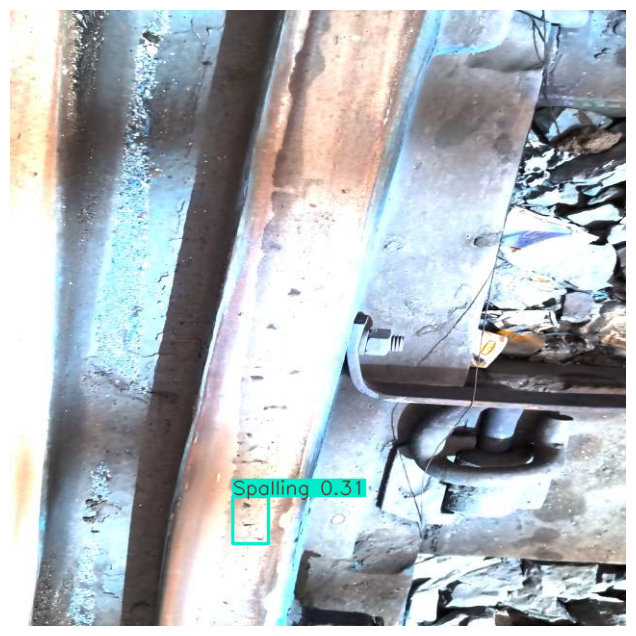

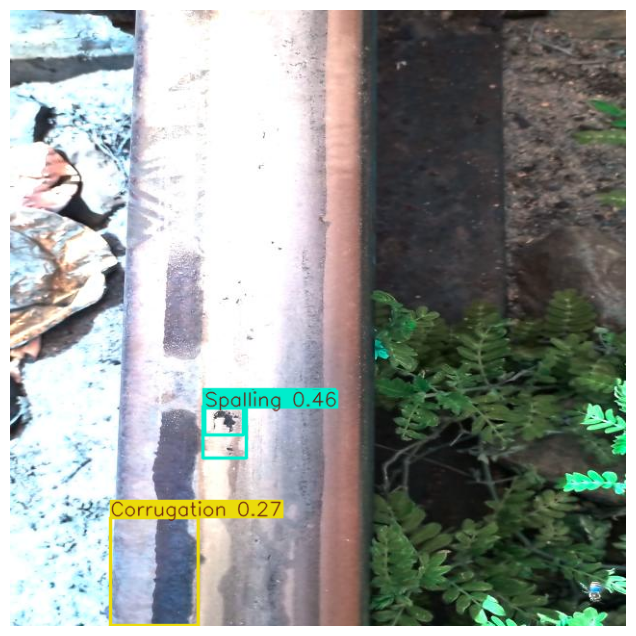

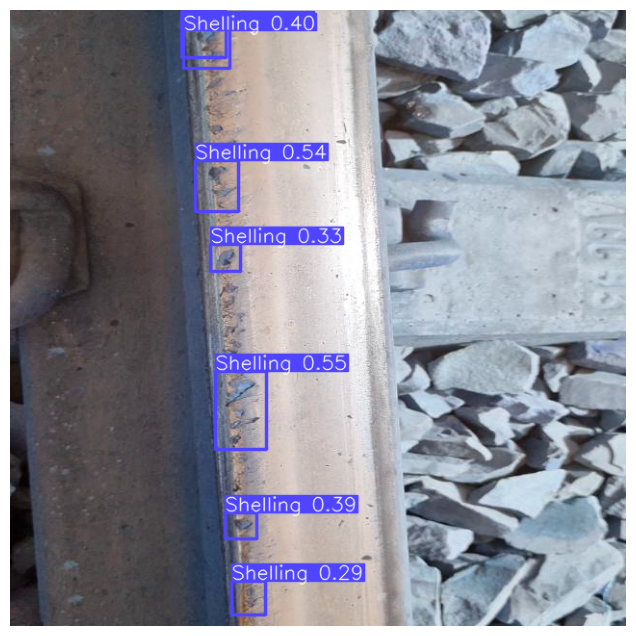

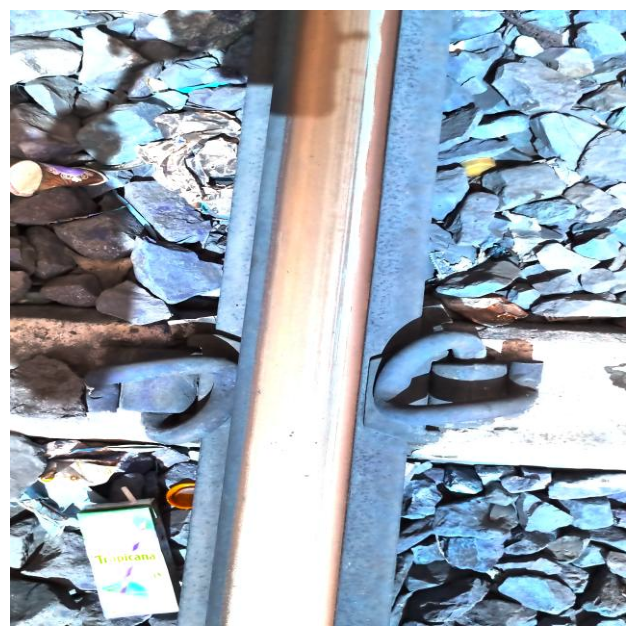

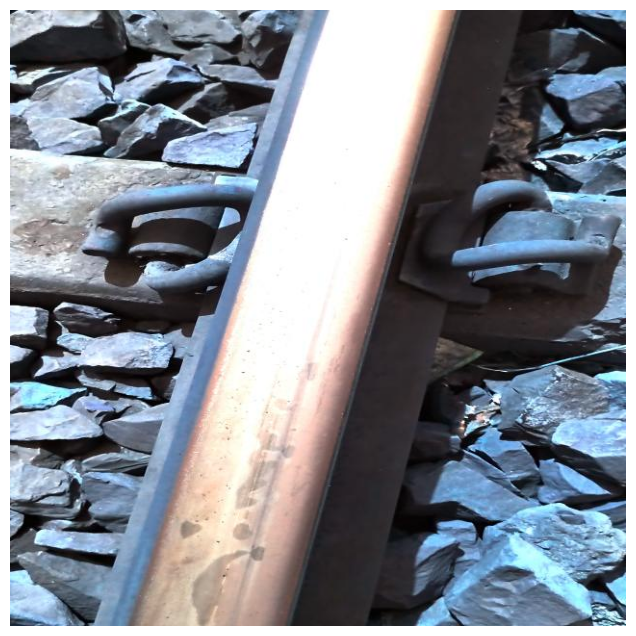

In [ ]:
for result in results:
    predicted_images=result.plot()
    plt.figure(figsize=(10,8))
    plt.imshow(predicted_images[..., ::1])
    plt.axis("off")
    plt.show()